# SmeshBot benchmark + MLflow logging

Benchmarks `agents.smesh_bot.SmeshBot` (the rule-based AI used as a training
opponent) against a few baseline brains over many headless matches, and logs the
results to MLflow so changes to its difficulty parameters can be compared across
revisions.

Per matchup, this tracks:
- **win rate** (player 0 = SmeshBot)
- **average match length** (frames)
- **average damage dealt / taken** per match
- **self-KO rate** — fraction of matches where SmeshBot lost a stock without being
  hit in the previous `SELF_KO_WINDOW` frames (i.e. it walked/fell to its death on
  its own). This is the failure mode the border-edge fix addressed, so it doubles
  as a regression check.

Drives `Match` directly (headless, no Gym env / Pygame window needed).

In [15]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from smeshlite.core.match import Match, MatchConfig
from smeshlite.data.stage_data import DEFAULT_STAGE
from agents.smesh_bot import SmeshBot
from agents.chaser_bot import ChaserBot
from agents.random_bot import RandomBot

## Match runner

Plays one full headless match between two brains and extracts summary stats.
"Self-KO" = a stock lost without a recorded `damage_event` against that player in
the previous `SELF_KO_WINDOW` frames. For each self-KO, the triggering player, frame
number, and (x, y) position at the moment of death are also recorded (`self_ko_events`)
so the *where/when* of self-destructs can be inspected later.

In [16]:
SELF_KO_WINDOW = 30  # frames (~0.5s at 30fps)


def run_match(brain_a, brain_b, max_frames=7200):
    """Play one headless match. brain_a/brain_b are CharacterBrain factories (no-arg callables)."""
    m = Match(MatchConfig(time_limit=max_frames))
    m.reset(n_players=2)
    m.set_player_brain(0, brain_a())
    m.set_player_brain(1, brain_b())

    dmg_dealt = [0.0, 0.0]
    last_hit_frame = [-SELF_KO_WINDOW - 1, -SELF_KO_WINDOW - 1]
    kos_against = [0, 0]
    self_kos = [0, 0]
    self_ko_events = []
    prev_stocks = [c.stocks for c in m.characters]

    while not m.done:
        info = m.tick()
        for ev in info.get("damage_events", []):
            dmg_dealt[ev["attacker"]] += ev["damage"]
            last_hit_frame[ev["target"]] = m.frame

        for i, c in enumerate(m.characters):
            if c.stocks < prev_stocks[i]:
                kos_against[i] += 1
                if m.frame - last_hit_frame[i] > SELF_KO_WINDOW:
                    self_kos[i] += 1
                    self_ko_events.append({
                        "player": i,
                        "frame": m.frame,
                        "x": c.x,
                        "y": c.y,
                    })
                prev_stocks[i] = c.stocks

    return {
        "winner": m.winner,
        "frames": m.frame,
        "p0_dmg_dealt": dmg_dealt[0],
        "p1_dmg_dealt": dmg_dealt[1],
        "p0_kos_against": kos_against[0],
        "p1_kos_against": kos_against[1],
        "p0_self_kos": self_kos[0],
        "p1_self_kos": self_kos[1],
        "self_ko_events": self_ko_events,
    }

## Run the benchmark

SmeshBot (player 0) vs. each baseline (player 1), `N_MATCHES` matches per matchup.
Each match re-seeds Python's `random` module for reproducibility.

In [17]:
import random

N_MATCHES = 1000

MATCHUPS = {
    "vs RandomBot": RandomBot,
    "vs ChaserBot": ChaserBot,
    "vs SmeshBot (mirror)": SmeshBot,
}

rows = []
for name, opponent_cls in MATCHUPS.items():
    for seed in range(N_MATCHES):
        random.seed(seed)
        result = run_match(SmeshBot, opponent_cls)
        result["matchup"] = name
        result["seed"] = seed
        rows.append(result)

df = pd.DataFrame(rows)
df.head()

,winner,frames,p0_dmg_dealt,p1_dmg_dealt,p0_kos_against,p1_kos_against,p0_self_kos,p1_self_kos,self_ko_events,matchup,seed
0,0,5843,125.0,510.0,0,3,0,3,"[{'player': 1, 'frame': 1295, 'x': 372.4774194...",vs RandomBot,0
1,0,2595,59.0,201.0,0,3,0,3,"[{'player': 1, 'frame': 1756, 'x': 399.3997635...",vs RandomBot,1
2,0,1913,52.0,145.0,0,3,0,3,"[{'player': 1, 'frame': 367, 'x': 384.99546750...",vs RandomBot,2
3,0,2384,82.0,102.0,0,3,0,3,"[{'player': 1, 'frame': 596, 'x': 451.27812603...",vs RandomBot,3
4,0,3522,144.0,336.0,0,3,0,3,"[{'player': 1, 'frame': 655, 'x': 362.92003201...",vs RandomBot,4


## Summary per matchup

In [18]:
summary = df.groupby("matchup", sort=False).agg(
    win_rate=("winner", lambda w: (w == 0).mean()),
    avg_frames=("frames", "mean"),
    avg_dmg_dealt=("p0_dmg_dealt", "mean"),
    avg_dmg_taken=("p1_dmg_dealt", "mean"),
    avg_kos=("p1_kos_against", "mean"),
    avg_deaths=("p0_kos_against", "mean"),
    self_ko_rate=("p0_self_kos", lambda s: (s > 0).mean()),
).reset_index()
summary

,matchup,win_rate,avg_frames,avg_dmg_dealt,avg_dmg_taken,avg_kos,avg_deaths,self_ko_rate
0,vs RandomBot,1.000,2321.282,78.583,216.359,2.996,0.001,0.001
1,vs ChaserBot,0.980,5531.527,517.221,82.934,2.069,0.155,0.105
2,vs SmeshBot (mirror),0.486,6594.123,730.537,733.979,1.903,1.934,0.977


## Log to MLflow

Requires `pip install mlflow` (see the `bench` extra in `pyproject.toml`). Each
matchup is logged as a nested run under a parent `smesh_bot_benchmark` run, so
results from different code revisions / parameter sets can be compared in the
MLflow UI (`mlflow ui`).

In [19]:
import inspect
import mlflow

mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("smesh_bot_benchmark_x10000")

# SmeshBot's difficulty constants, as currently configured (its __init__ defaults).
_sig = inspect.signature(SmeshBot.__init__)
_bot = SmeshBot()
smesh_bot_params = {name: getattr(_bot, name) for name in _sig.parameters if name != "self"}

with mlflow.start_run(run_name=f"benchmark_{time.strftime('%Y%m%d_%H%M%S')}"):
    mlflow.log_param("n_matches_per_matchup", N_MATCHES)
    mlflow.log_param("self_ko_window_frames", SELF_KO_WINDOW)
    for k, v in smesh_bot_params.items():
        mlflow.log_param(f"smesh_bot.{k}", v)

    for _, row in summary.iterrows():
        with mlflow.start_run(run_name=row["matchup"], nested=True):
            mlflow.log_param("matchup", row["matchup"])
            for metric in ("win_rate", "avg_frames", "avg_dmg_dealt", "avg_dmg_taken",
                           "avg_kos", "avg_deaths", "self_ko_rate"):
                mlflow.log_metric(metric, row[metric])

print("Logged to MLflow. Run `mlflow ui` and open http://127.0.0.1:5000 to inspect.")

2026/06/14 23:32:23 INFO mlflow.tracking.fluent: Experiment with name 'smesh_bot_benchmark_x10000' does not exist. Creating a new experiment.


🏃 View run vs RandomBot at: http://localhost:5000/#/experiments/6/runs/c813f89b059c4102a203b9b70c0ac2fc
🧪 View experiment at: http://localhost:5000/#/experiments/6
🏃 View run vs ChaserBot at: http://localhost:5000/#/experiments/6/runs/020e16d43aa14b98a5c7c1fa2753e286
🧪 View experiment at: http://localhost:5000/#/experiments/6
🏃 View run vs SmeshBot (mirror) at: http://localhost:5000/#/experiments/6/runs/2077316719964d27867c4253636f629c
🧪 View experiment at: http://localhost:5000/#/experiments/6
🏃 View run benchmark_20260614_233223 at: http://localhost:5000/#/experiments/6/runs/0cc217a2fc744f30baf93feb66168443
🧪 View experiment at: http://localhost:5000/#/experiments/6
Logged to MLflow. Run `mlflow ui` and open http://127.0.0.1:5000 to inspect.


## Visualize

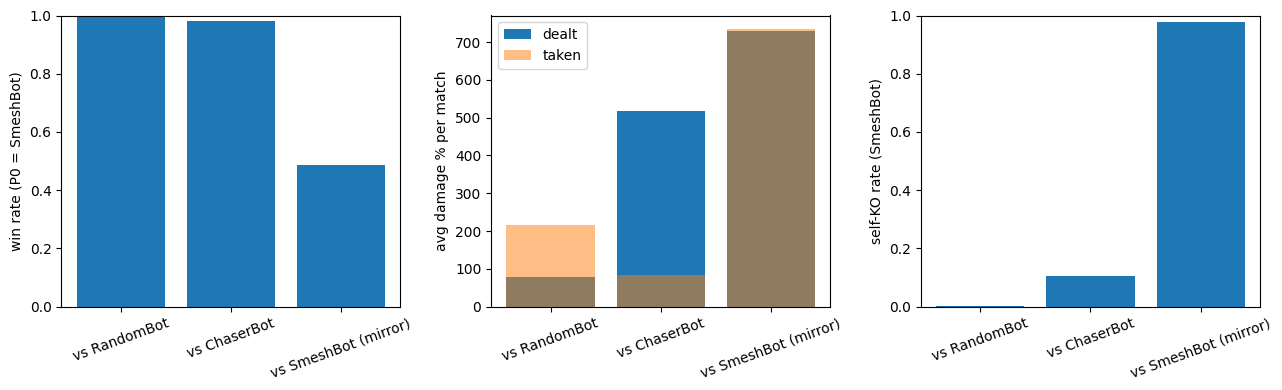

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

axes[0].bar(summary["matchup"], summary["win_rate"])
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("win rate (P0 = SmeshBot)")
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(summary["matchup"], summary["avg_dmg_dealt"], label="dealt")
axes[1].bar(summary["matchup"], summary["avg_dmg_taken"], alpha=0.5, label="taken")
axes[1].set_ylabel("avg damage % per match")
axes[1].tick_params(axis="x", rotation=20)
axes[1].legend()

axes[2].bar(summary["matchup"], summary["self_ko_rate"])
axes[2].set_ylim(0, 1)
axes[2].set_ylabel("self-KO rate (SmeshBot)")
axes[2].tick_params(axis="x", rotation=20)

fig.tight_layout()

## Behavior profile: damage dealt vs. kills scored

Per-match scatter of damage dealt by SmeshBot (x) against stocks taken from the
opponent (y, 0-3). This characterizes *what kind of bot* SmeshBot is: a cluster
toward high damage / low kills marks a "damager" archetype (racks up damage but
struggles to close stocks), while a cluster toward low damage / high kills would
mark an efficient "killer" archetype. Useful as a quick behavioral fingerprint to
compare against other agents (e.g. QTableBot, DeepQBot) once they're trained.

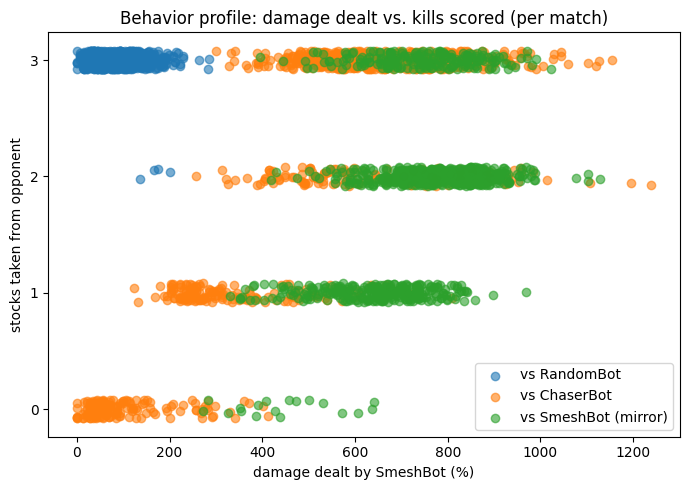

In [21]:
rng = np.random.default_rng(0)

fig, ax = plt.subplots(figsize=(7, 5))
for matchup, group in df.groupby("matchup", sort=False):
    jitter = rng.uniform(-0.08, 0.08, size=len(group))
    ax.scatter(group["p0_dmg_dealt"], group["p1_kos_against"] + jitter,
               alpha=0.6, label=matchup)

ax.set_xlabel("damage dealt by SmeshBot (%)")
ax.set_ylabel("stocks taken from opponent")
ax.set_yticks([0, 1, 2, 3])
ax.set_title("Behavior profile: damage dealt vs. kills scored (per match)")
ax.legend()
fig.tight_layout()

## Win rate vs. match length

Match-length distributions split by winner, per matchup. Shows whether SmeshBot's
wins/losses are concentrated at particular match lengths (e.g. fast decisive wins
vs. drawn-out losses), as opposed to win rate being independent of how long the
match runs.

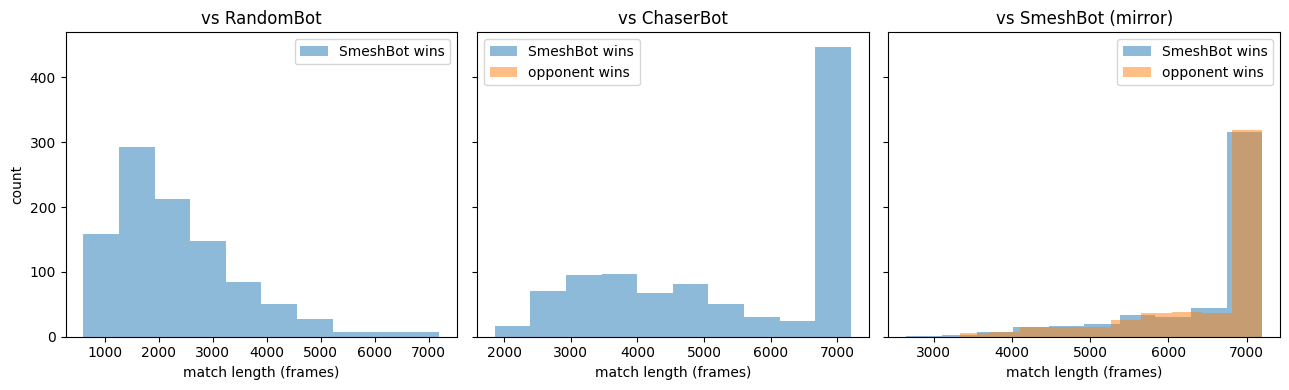

In [22]:
matchups = list(df["matchup"].unique())
fig, axes = plt.subplots(1, len(matchups), figsize=(13, 4), sharey=True)

for ax, matchup in zip(axes, matchups):
    group = df[df["matchup"] == matchup]
    for winner, sub in group.groupby("winner"):
        label = "SmeshBot wins" if winner == 0 else "opponent wins"
        ax.hist(sub["frames"], bins=10, alpha=0.5, label=label)
    ax.set_title(matchup)
    ax.set_xlabel("match length (frames)")
    ax.legend()

axes[0].set_ylabel("count")
fig.tight_layout()

## Self-KO diagnostics: where and when SmeshBot dies on its own

SmeshBot is notorious for self-destructing. `self_ko_events` (collected per match in
`run_match`) records the player, frame, and (x, y) position at the moment of each
self-KO. Exploding that into its own dataframe lets us check:

- **where** on stage self-KOs happen (clustered near platform edges would point at
  the border-edge issue the self-KO fix targeted), relative to the stage geometry
  and kill bounds (`DEFAULT_STAGE`)
- **when** in the match they happen (early vs. late)

In [23]:
self_ko_rows = []
for _, row in df.iterrows():
    for ev in row["self_ko_events"]:
        self_ko_rows.append({
            "matchup": row["matchup"],
            "seed": row["seed"],
            "player": ev["player"],
            "frame": ev["frame"],
            "frame_frac": ev["frame"] / row["frames"],
            "x": ev["x"],
            "y": ev["y"],
        })

self_ko_df = pd.DataFrame(self_ko_rows)
p0_self_ko_df = self_ko_df[self_ko_df["player"] == 0]
print(f"{len(self_ko_df)} total self-KO events, {len(p0_self_ko_df)} by SmeshBot (player 0)")
self_ko_df.head()

8516 total self-KO events, 1992 by SmeshBot (player 0)


,matchup,seed,player,frame,frame_frac,x,y
0,vs RandomBot,0,1,1295,0.221633,372.477419,-359.85028
1,vs RandomBot,0,1,3062,0.524046,356.063217,-358.75028
2,vs RandomBot,0,1,5843,1.000000,406.850599,-360.95028
3,vs RandomBot,1,1,1756,0.676686,399.399764,-352.75028
4,vs RandomBot,1,1,1958,0.754528,356.081488,-350.45028


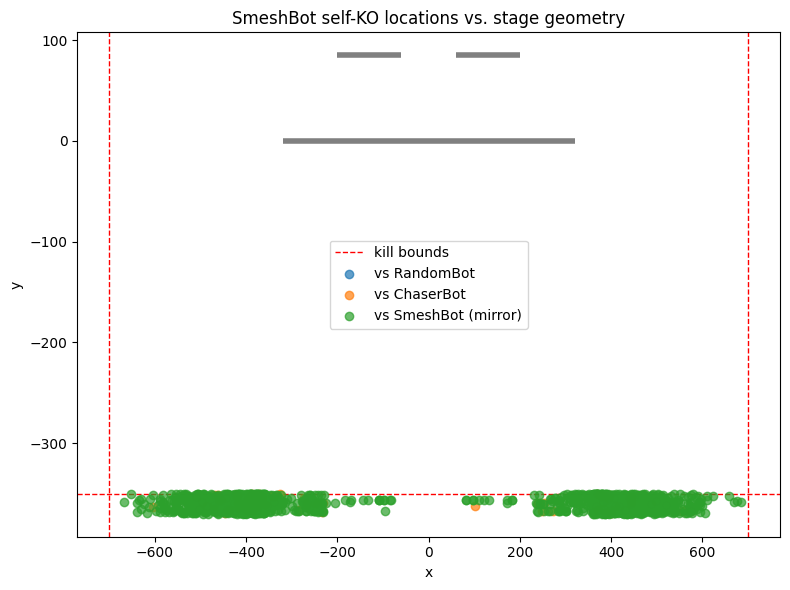

In [24]:
fig, ax = plt.subplots(figsize=(8, 6))

for plat in DEFAULT_STAGE.platforms:
    ax.plot([plat.x1, plat.x2], [plat.y, plat.y], color="gray", linewidth=4,
            solid_capstyle="butt", zorder=1)

ax.axvline(-DEFAULT_STAGE.kill_x, color="red", linestyle="--", linewidth=1, label="kill bounds")
ax.axvline(DEFAULT_STAGE.kill_x, color="red", linestyle="--", linewidth=1)
ax.axhline(-DEFAULT_STAGE.kill_y, color="red", linestyle="--", linewidth=1)

for matchup, group in p0_self_ko_df.groupby("matchup", sort=False):
    ax.scatter(group["x"], group["y"], alpha=0.7, label=matchup, zorder=2)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("SmeshBot self-KO locations vs. stage geometry")
ax.legend()
fig.tight_layout()

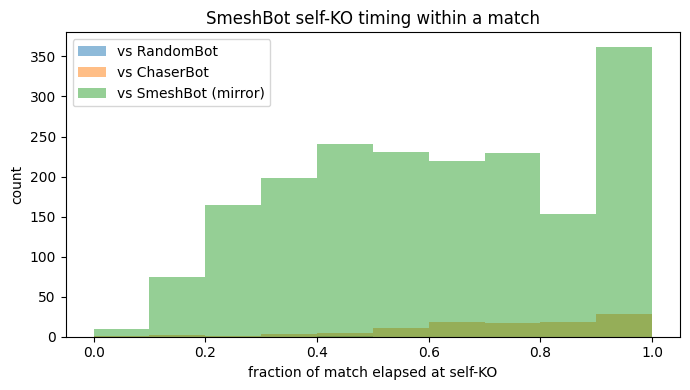

In [25]:
fig, ax = plt.subplots(figsize=(7, 4))

for matchup, group in p0_self_ko_df.groupby("matchup", sort=False):
    ax.hist(group["frame_frac"], bins=10, range=(0, 1), alpha=0.5, label=matchup)

ax.set_xlabel("fraction of match elapsed at self-KO")
ax.set_ylabel("count")
ax.set_title("SmeshBot self-KO timing within a match")
ax.legend()
fig.tight_layout()